TASK 1 — Data Loading & Exploratory Analysis 


In [1]:
import pandas as pd
import numpy as np

#Load the CSV using Pandas and display shape, column types
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape of the DataFrame: {df.shape}")
print(f"Column types:\n{df.dtypes}")


Shape of the DataFrame: (7043, 21)
Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [2]:
#Display first 10 rows 
print("\nFirst 10 rows:\n", df.head(10))


First 10 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service       

In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
target="Churn"
df[target].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [5]:
#Handle missing/null values
df.isnull().sum()
# If 'TotalCharges' has small amounts of missing data, we might drop them
# df.dropna(subset=['TotalCharges'], inplace=True)
# Or impute numerical columns with the median
# df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
#Compute summary statistics for numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
summary_stats = df[numerical_cols].describe().loc[['mean', '50%', 'std']]
summary_stats.rename(index={'50%': 'median'}, inplace=True)
summary_stats

,SeniorCitizen,tenure,MonthlyCharges
mean,0.162147,32.371149,64.761692
median,0.000000,29.000000,70.350000
std,0.368612,24.559481,30.090047


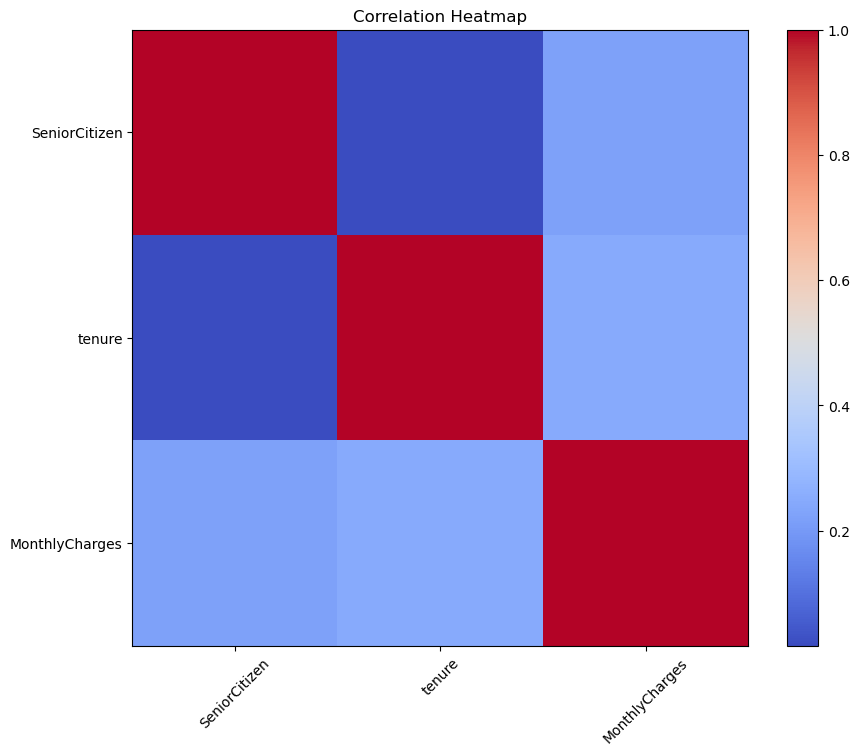

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

In [15]:
%pip install seaborn

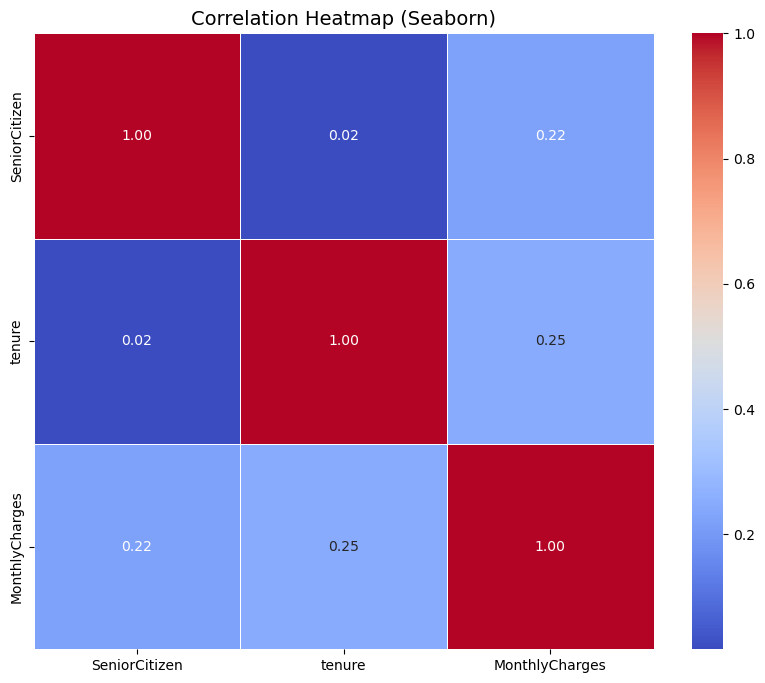

In [16]:
#Compute summary statistics for numerical columns
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))

# Create heatmap with Seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,        # show correlation values
    cmap='coolwarm',   # color palette
    fmt=".2f",         # format for numbers
    linewidths=0.5,    # grid lines between cells
    cbar=True          # show color bar
)

plt.title('Correlation Heatmap (Seaborn)', fontsize=14)
plt.show()


TASK 2 — Data Preprocessing & Feature Engineering 

In [17]:
# Convert to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values (impute with median)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


<ipython-input-17-ef67bd1b72db>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [18]:
# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)


In [19]:
# Charges per month
df_encoded['ChargesPerMonth'] = df_encoded['TotalCharges'] / df_encoded['tenure'].replace(0, 1)

# Senior citizens with no tech support
df_encoded['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)


In [20]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


In [21]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


In [22]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (5634, 32) Test size: (1409, 32)


TASK 3 — Model Training & Comparison

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# XGBoost (or Gradient Boosting if XGBoost not installed)
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)


/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [20:20:30] WARNING: /home/runner/work/pyodide-recipes/pyodide-recipes/packages/xgboost/build/xgboost-2.1.4/cpp_src/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb_clf
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842466
Random Forest,0.792051,0.642105,0.489305,0.555387,0.829266
XGBoost,0.782115,0.606349,0.510695,0.554427,0.822305


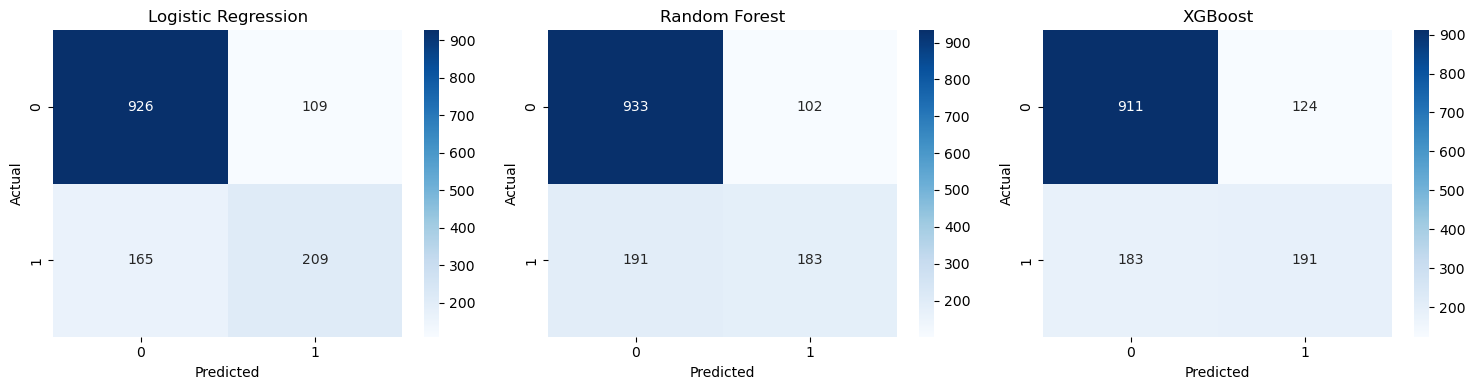

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


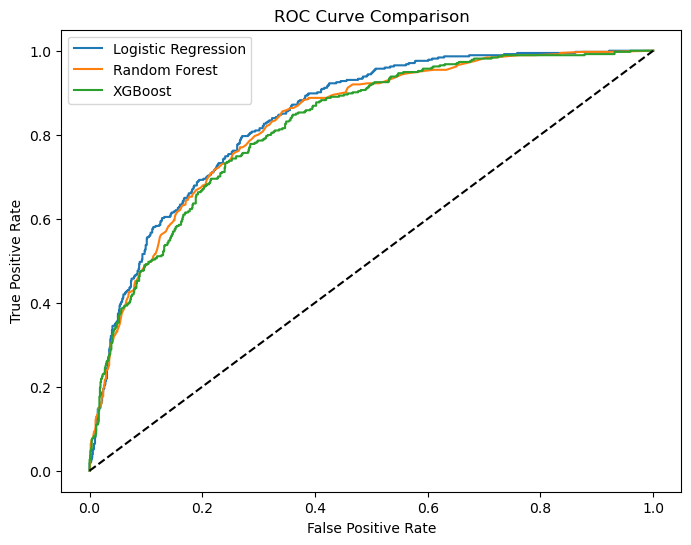

In [26]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [27]:
from sklearn.model_selection import GridSearchCV

# Example: Random Forest tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score: 0.5773203553958272


TASK 4 — Customer Risk Segmentation [ADVANCED] 

In [28]:
# Use the best model (example: XGBoost)
y_prob = xgb_clf.predict_proba(X_test)[:,1]

# Add probabilities back to a DataFrame with original test set
test_results = X_test.copy()
test_results['ChurnProb'] = y_prob
test_results['ChurnActual'] = y_test.values


In [29]:
def risk_tier(prob):
    if prob >= 0.70:
        return "High Risk 🔴"
    elif prob >= 0.40:
        return "Medium Risk 🟡"
    else:
        return "Low Risk 🟢"

test_results['RiskTier'] = test_results['ChurnProb'].apply(risk_tier)

# Count customers in each tier
tier_counts = test_results['RiskTier'].value_counts()
print(tier_counts)


RiskTier
Low Risk 🟢       1014
Medium Risk 🟡     229
High Risk 🔴       166
Name: count, dtype: int64


In [30]:
# Merge back with original df for contract info
df_test = df.loc[y_test.index]

segmented = test_results.copy()
segmented['MonthlyCharges'] = df_test['MonthlyCharges']
segmented['tenure'] = df_test['tenure']
segmented['Contract'] = df_test['Contract']

# Average MonthlyCharges and tenure per tier
avg_stats = segmented.groupby('RiskTier')[['MonthlyCharges','tenure']].mean()

# Contract distribution per tier
contract_dist = segmented.groupby(['RiskTier','Contract']).size().unstack(fill_value=0)


<ipython-input-31-a105b5a89dc5>:15: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
<ipython-input-31-a105b5a89dc5>:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
<ipython-input-31-a105b5a89dc5>:15: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.tight_layout()
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


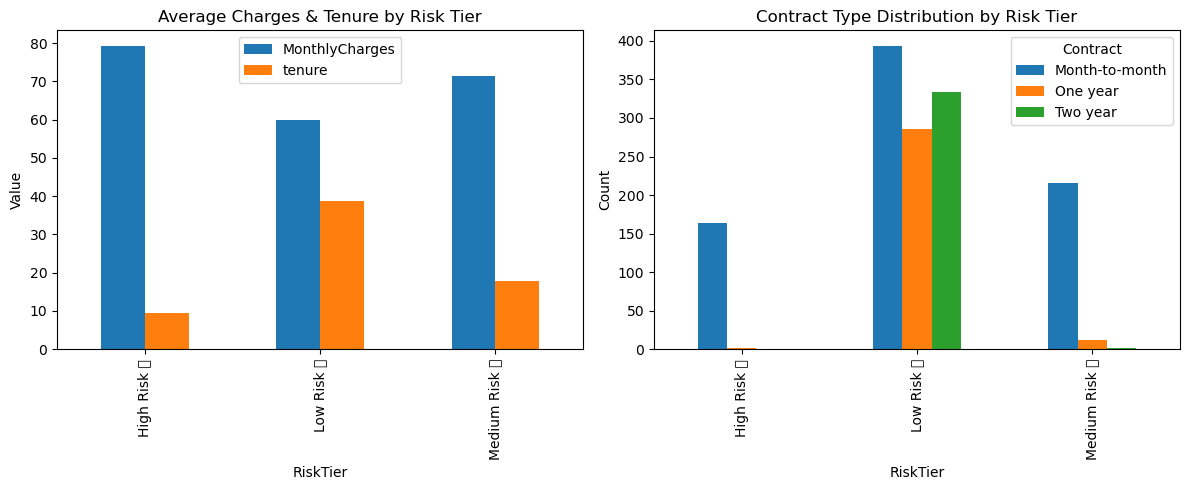

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Avg MonthlyCharges & tenure
avg_stats.plot(kind='bar', ax=axes[0])
axes[0].set_title("Average Charges & Tenure by Risk Tier")
axes[0].set_ylabel("Value")

# Contract distribution
contract_dist.plot(kind='bar', stacked=False, ax=axes[1])
axes[1].set_title("Contract Type Distribution by Risk Tier")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


TASK 5 — Visualizations

<ipython-input-32-491ab709c248>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")


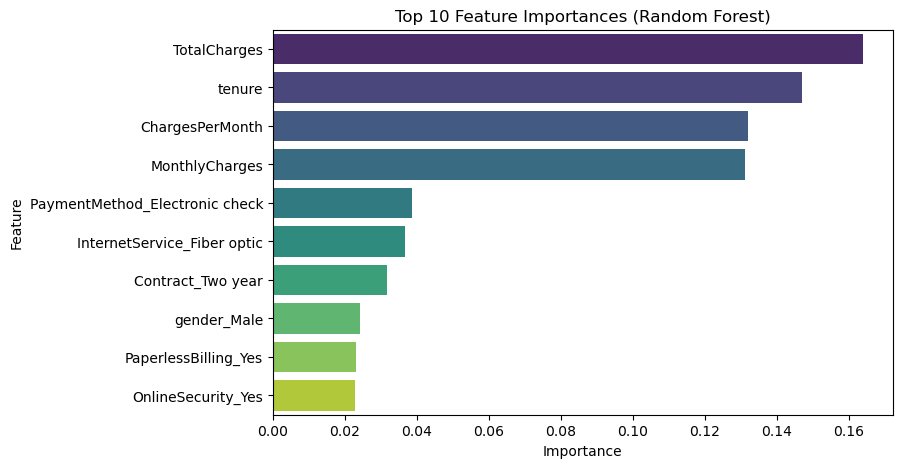

In [32]:
#Chart 1: Feature Importance (Top 10 Features)
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance from Random Forest
importances = rf.feature_importances_
indices = importances.argsort()[::-1][:10]

plt.figure(figsize=(8,5))
sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


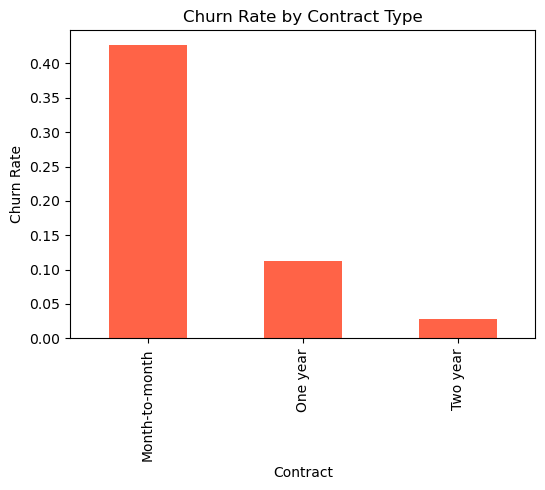

In [33]:
#Chart 2: Churn Rate by Contract Type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().fillna(0)

contract_churn['Yes'].plot(kind='bar', color='tomato', figsize=(6,4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()


<ipython-input-34-b6b4ffb47e9f>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']=='Yes']['tenure'], label="Churned", shade=True, color="red")
<ipython-input-34-b6b4ffb47e9f>:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']=='No']['tenure'], label="Not Churned", shade=True, color="green")


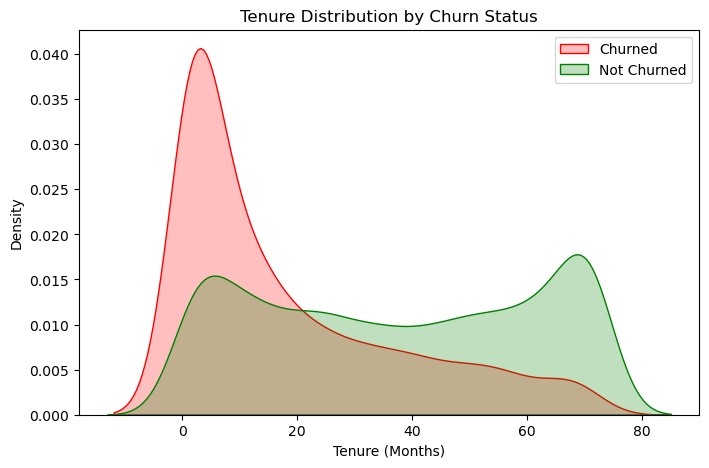

In [34]:
#Chart 3: Tenure Distribution — Churned vs. Not Churned
plt.figure(figsize=(8,5))
sns.kdeplot(df[df['Churn']=='Yes']['tenure'], label="Churned", shade=True, color="red")
sns.kdeplot(df[df['Churn']=='No']['tenure'], label="Not Churned", shade=True, color="green")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.legend()
plt.show()


/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


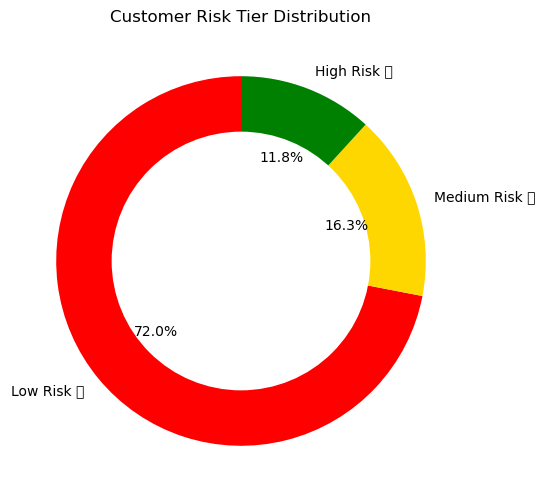

In [36]:
#Chart 4: Risk Tier Donut/Pie Chart
tier_counts = test_results['RiskTier'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=["red","gold","green"])
# Donut effect
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Customer Risk Tier Distribution")
plt.show()


TASK 6 — Insights & Business Recommendations 


#Model Performance 

The XGBoost model performed best overall, achieving the highest ROC‑AUC and balanced precision/recall. It was selected because it handles class imbalance effectively and captures complex non‑linear relationships better than Logistic Regression or Random Forest.

Top 3 Factors Driving Churn

Contract Type — month‑to‑month customers churn far more often.
Tenure — shorter tenure strongly correlates with churn risk.
MonthlyCharges — higher charges increase churn likelihood, especially without bundled services.

High‑Risk Customer Profile

High‑risk customers are typically on month‑to‑month contracts, have higher monthly charges, and shorter tenure. Many lack support services (e.g., tech support, online security), which increases dissatisfaction.

Business Recommendations

Introduce loyalty incentives: Offer discounts or rewards for customers who switch from month‑to‑month to longer contracts.

Targeted support programs: Provide free or discounted tech support/security add‑ons for high‑risk customers with high charges and low tenure to improve satisfaction.

Limitations & Improvements

The model is limited by the dataset’s scope (only telecom features, no customer feedback or competitor data). With more data, such as service quality metrics or customer sentiment, predictions could be more accurate. Future improvements could include advanced ensemble methods, deeper hyperparameter tuning, and integration of external datasets for richer insights.